# MERIDA


In [1]:
from google.cloud import bigquery
from google.cloud import storage
import numpy as np
import pandas as pd
import geopandas as gpd
import datetime as dt
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.ticker import ScalarFormatter, MultipleLocator
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from matplotlib.gridspec import GridSpec
from decimal import *
from calendar import monthrange, month_abbr
import cartopy as ctp
import cartopy.crs as ccrs
import cartopy.io.img_tiles as cimgt
from cartopy.io import shapereader
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import io
import base64
import pygrib
import math
import netCDF4
import pytz
import cmocean
import seaborn as sns
from sklearn.metrics import mean_squared_error, confusion_matrix
import matplotlib.dates as mdates
from pytz import timezone, all_timezones
from scipy.stats import spearmanr, pearsonr, linregress
import scipy.signal as signal
from scipy.interpolate import interp1d
from taylor_diagram import TaylorDiagram
import statsmodels.api as sm
import os
import difflib
import folium
from folium.plugins import MarkerCluster, BeautifyIcon
from PIL import Image, ImageDraw
import warnings
import properscoring as ps
import numba
import pprint
from geopy.distance import geodesic
import xarray as xr
from glob import glob
from scipy.stats import mode

## Function to load Merida Reanalysis

In [2]:
years_merida = [i for i in range(2011, 2024)]
months_merida = [i for i in range(5, 9)] # May to August

In [3]:
def open_merida(var, year, month):
    """
    Open Merida data for a specific variable, year, and month.
    Use xarray to read the NetCDF file.
    Args:
        var (str): Variable name (SOIL_M, T2, Q2, SOIL_T, SWDDIR, SWDDIF).
        year (int): Year of the data.
        month (int): Month of the data (1-12).
    """
    # Define the file path with the specific file name
    file_path = f"D:/data_a2a/merida/MERIDA_{var}_{year}{month:02d}.nc"
    
    # Check if the file exists
    if not os.path.isfile(file_path):
        raise FileNotFoundError(f"File not found: {file_path}")
    
    # Open the NetCDF file using xarray
    ds = xr.open_dataset(file_path)
    
    # Return the dataset
    return ds

In [276]:
filetest = open_merida('LWRAD', 2023, 5)
display(filetest)

<xarray.Dataset> Size: 104MB
Dimensions:  (time: 744, lon: 188, lat: 185)
Coordinates:
  * time     (time) datetime64[ns] 6kB 2023-05-01 ... 2023-05-31T23:00:00
  * lon      (lon) float32 752B 5.84 5.91 5.98 6.05 ... 18.72 18.79 18.86 18.93
  * lat      (lat) float32 740B 48.25 48.18 48.11 48.04 ... 35.51 35.44 35.37
Data variables:
    ulwrf    (time, lat, lon) float32 104MB ...
Attributes:
    Conventions:    CF-1.6
    title:          MERIDA - MEteorological Reanalysis Italian DAtaset
    version:        v1
    driving_model:  ERA5
    source:         WRF3.9
    resolution:     0.07 deg - regular lat-lon
    frequency:      1 hr
    institution:    RSE S.p.A. - Ricerca sul Sistema Energetico
    references:     Bonanno,R., Lacavalla,M., Sperati,S.,2019. A new high-res...
    founding:       This work has been financed by the Research Fund for the ...

In [5]:
def load_multiple_variables(vars, years=years_merida, months=months_merida, data_dir="D:/data_a2a/merida/", lat_bounds=None, lon_bounds=None):
    """
    Get Merida data from the SD card data_a2a/merida
    
    Args:
        variables (list): Variable names (SOIL_M, T2, Q2, SOIL_T, SWDDIR, SWDDIF).
        years (list): List of years to include in the data.
        months (list): List of months to include in the data.
        data_dir (str): Directory where the data files are stored.
        lat_bounds (tuple): Latitude bounds for filtering the data (min_lat, max_lat).
        lon_bounds (tuple): Longitude bounds for filtering the data (min_lon, max_lon).
    Returns:
        combined_ds (xarray.Dataset): Merged dataset containing the specified variables.
    """
    datasets = []

    for var in vars:
        file_pattern = os.path.join(data_dir, f"MERIDA_{var}_*.nc")
        files = sorted(glob(file_pattern))
        # Filter files based on years and months
        filtered_files = [f for f in files if int(f.split("_")[-1][:4]) in years and int(f.split("_")[-1][4:6]) in months]
        if not filtered_files:
            raise FileNotFoundError(f"No files found for variable {var} and years {years}, month {months} in {data_dir}")

        # Load the dataset for the variable
        ds = xr.open_mfdataset(filtered_files, combine="nested", concat_dim="time", chunks=None)

        # Ensure unique time values
        if ds.indexes["time"].duplicated().any():
            print(var)
            ds = ds.sel(time=~ds.indexes["time"].duplicated())

        # Filter the dataset based on latitude and longitude bounds if provided
        if lat_bounds is not None and lon_bounds is not None:
            ds = ds.sel(lat=slice(lat_bounds[1], lat_bounds[0]), lon=slice(lon_bounds[0], lon_bounds[1]))
        
        datasets.append(ds)

    # Merge all datasets into one
    combined_ds = xr.merge(datasets)
    
    return combined_ds


In [6]:
temperature_ds = load_multiple_variables(['T2', 'SOIL_T'], 
                                      years=years_merida, months=months_merida, 
                                     data_dir="D:/data_a2a/merida/", lat_bounds=(45.3, 45.7), lon_bounds=(8.95, 9.4))


In [7]:
humidity_ds= load_multiple_variables(['Q2', 'SOIL_M'], 
                                      years=years_merida, months=months_merida, 
                                     data_dir="D:/data_a2a/merida/", lat_bounds=(45.3, 45.7), lon_bounds=(8.95, 9.4))


Q2


In [8]:
flux_ds = load_multiple_variables(['SWDDIR', 'SWDDIF', 'GRDFLX', 'HFX', 'LH', 'LWRAD', 'TR'],
                                    years=years_merida, months=months_merida, 
                                     data_dir="D:/data_a2a/merida/", lat_bounds=(45.3, 45.7), lon_bounds=(8.95, 9.4))


SWDDIR
SWDDIF


In [9]:
precip_ds = load_multiple_variables(['PREC'],
                                    years=years_merida, months=months_merida, 
                                     data_dir="D:/data_a2a/merida/", lat_bounds=(45.3, 45.7), lon_bounds=(8.95, 9.4))

In [10]:
wind_ds = load_multiple_variables(['U10', 'V10'],
                                    years=years_merida, months=months_merida, 
                                     data_dir="D:/data_a2a/merida/", lat_bounds=(45.3, 45.7), lon_bounds=(8.95, 9.4))

U10
V10


In [11]:
#combined_ds.load() # very long

In [12]:
def plot_onetime_merida(dataset, var, time, colormap='viridis', vmin=None, vmax=None):
    """
    Plot the Merida dataset using xarray and matplotlib at the specified time.
    Args:
        dataset (xarray.Dataset): The dataset to plot.
        time (str): The time to plot in the format 'YYYY-MM-DD HH:MM:SS'.
        var (str): The variable to plot, should be present in the dataset (e.g. 't2m', 'st')
    """

    var_name = var
    if var_name not in dataset.variables:
        raise ValueError(f"Variable {var_name} not found in the dataset. Available variables: {list(dataset.variables.keys())}")
    unit = dataset[var_name].units
    long_name = dataset[var_name].long_name if 'long_name' in dataset[var_name].attrs else var_name
    index_time_selected= np.where(dataset.time.values == np.datetime64(time))[0][0]

    # check if coordinate depth is present for the variable, if yes select 0.7m depth
    if 'depth' in dataset[var_name].dims:
        depth = dataset['depth'].values
        if len(depth) > 1:
            depth_index = np.where(depth == 0.7)[0][0]
            dataset = dataset.isel(depth=depth_index)
            level = f'{depth[depth_index]} m'
        elif len(depth) == 1:
            dataset = dataset.isel(depth=0)
            level = f'depth {depth[0]} m'
        else:
            raise ValueError("Depth coordinate is empty or not found in the dataset.")
    else:
        level = 'S'

    # plot the data on a map
    fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()})
    ax.add_feature(ctp.feature.LAND, facecolor='lightgray')
    ax.add_feature(ctp.feature.COASTLINE, edgecolor='black')
    ax.add_feature(ctp.feature.BORDERS, edgecolor='black')

    # Add gridlines
    gl = ax.gridlines(draw_labels=True, alpha=0.5, linestyle='--')
    gl.xlocator = MultipleLocator(0.2)
    gl.ylocator = MultipleLocator(0.2)

    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    gl.xlabel_style = {'size': 12}
    gl.ylabel_style = {'size': 12}
    gl.right_labels = False
    gl.top_labels = False
    
    # plot the data
    data = dataset[var_name].isel(time=index_time_selected).values
    lons = dataset['lon'].values
    lats = dataset['lat'].values

    im = ax.pcolormesh(lons, lats, data, cmap=colormap, shading='nearest', vmin=vmin, vmax=vmax)
    cax = fig.add_axes([0.92, 0.2, 0.02, 0.6])  # [left, bottom, width, height]
    cbar = plt.colorbar(im, cax=cax, orientation='vertical', pad=0.02, aspect=50)
    cbar.set_label(f'{long_name} ({unit})', fontsize=12)
    cbar.ax.tick_params(labelsize=10)

    ## also plot the Milano comune shapefile, CRS is ETRF00
    milano_shp = shapereader.Reader("shapefiles/L090102_ComuneMilano.shp")
    milano_geom = [record.geometry for record in milano_shp.records()]
    milano_gdf = gpd.GeoDataFrame(geometry=milano_geom, crs='EPSG:3003') # Roma40 Gauss-Boaga 
    milano_gdf = milano_gdf.to_crs(epsg=4326)
    for geom in milano_gdf.geometry:
        ax.add_geometries([geom], crs=ccrs.PlateCarree(), edgecolor='black', facecolor='none', linewidth=.5)

    # title
    ax.set_title(f'{var_name}, level: {level}\n{np.datetime_as_string(dataset.time.values[index_time_selected], unit='s').replace('T', ' ')}', fontsize=12, loc='right')
    ax.set_title(f'MERIDA', fontsize=12, loc='left')
    plt.show()

    return None


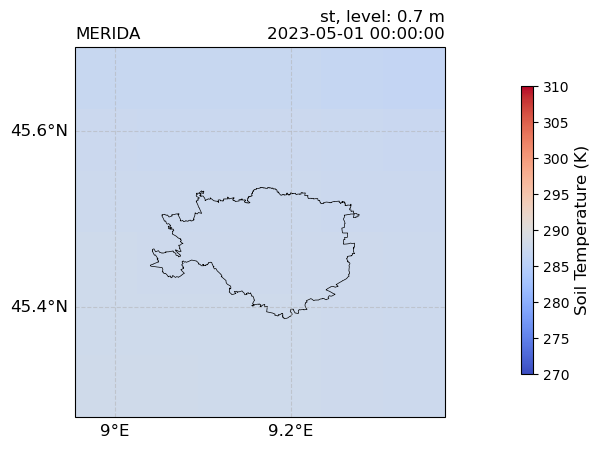

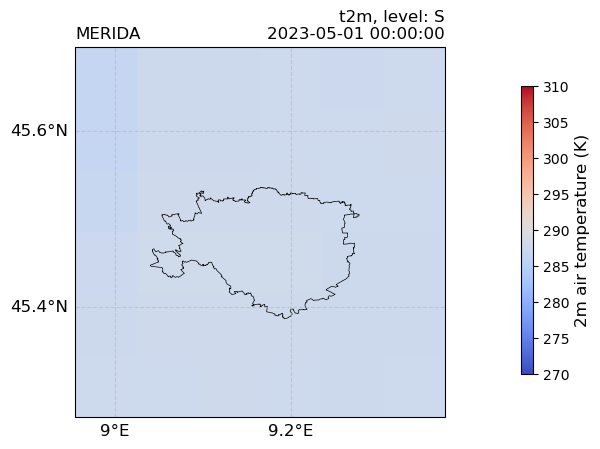

In [13]:
this_time = '2023-05-01 00:00:00'
plot_onetime_merida(temperature_ds, 'st', time=this_time, colormap='coolwarm', vmin=270, vmax=310)
plot_onetime_merida(temperature_ds, 't2m', time=this_time, colormap='coolwarm', vmin=270, vmax=310)

In [14]:
def clip_dataset(dataset, shapefile_path="shapefiles/L090102_ComuneMilano.shp"):
    """
    Clip the dataset to the boundaries of the Milan comune using a shapefile.
    Args:
        dataset (xarray.Dataset): The dataset to clip.
        shapefile_path (str): Path to the shapefile for Milan boundaries.
    Returns:
        dataset_clipped (xarray.Dataset): Clipped dataset.
        milano_gdf (geopandas.GeoDataFrame): GeoDataFrame of the Milan boundaries.
    """

    # Load the Milan shapefile
    milano_shp = shapereader.Reader(shapefile_path)
    milano_geom = [record.geometry for record in milano_shp.records()]
    milano_gdf = gpd.GeoDataFrame(geometry=milano_geom, crs='EPSG:3003')  # Roma40 Gauss-Boaga
    milano_gdf = milano_gdf.to_crs(epsg=4326)  # Convert to WGS84

    # Clip the dataset to the Milan boundaries
    milano_bounds = milano_gdf.total_bounds  # [min_lon, min_lat, max_lon, max_lat]
    dataset_clipped = dataset.sel(
        lon=slice(milano_bounds[0], milano_bounds[2]),
        lat=slice(milano_bounds[3], milano_bounds[1])
    )

    return dataset_clipped, milano_gdf

In [15]:
temperature_ds_clipped, milano_gdf = clip_dataset(temperature_ds, shapefile_path="shapefiles/L090102_ComuneMilano.shp")
humidity_ds_clipped, _ = clip_dataset(humidity_ds, shapefile_path="shapefiles/L090102_ComuneMilano.shp")
flux_ds_clipped, _ = clip_dataset(flux_ds, shapefile_path="shapefiles/L090102_ComuneMilano.shp")
wind_ds_clipped, _ = clip_dataset(wind_ds, shapefile_path="shapefiles/L090102_ComuneMilano.shp")
precip_ds_clipped, _ = clip_dataset(precip_ds, shapefile_path="shapefiles/L090102_ComuneMilano.shp")

In [16]:
temperature_ds_clipped.load()

<xarray.Dataset> Size: 9MB
Dimensions:     (time: 38376, lon: 4, lat: 2, depth: 4, bnds: 2)
Coordinates:
  * time        (time) datetime64[ns] 307kB 2011-05-01 ... 2023-08-31T23:00:00
  * lon         (lon) float32 16B 9.06 9.13 9.2 9.27
  * lat         (lat) float32 8B 45.52 45.45
  * depth       (depth) float64 32B 0.05 0.25 0.7 1.5
Dimensions without coordinates: bnds
Data variables:
    t2m         (time, lat, lon) float32 1MB 284.4 284.4 284.4 ... 290.9 291.0
    depth_bnds  (time, depth, bnds) float64 2MB 0.0 0.1 0.1 0.4 ... 1.0 1.0 2.0
    st          (time, depth, lat, lon) float32 5MB 287.9 287.9 ... 295.7 295.7
Attributes:
    Conventions:    CF-1.6
    title:          MERIDA - MEteorological Reanalysis Italian DAtaset
    version:        v1
    driving_model:  ERA5
    source:         WRF3.9
    resolution:     0.07 deg - regular lat-lon
    frequency:      1 hr
    institution:    RSE S.p.A. - Ricerca sul Sistema Energetico
    references:     Bonanno,R., Lacavalla,M., Sperati,S.,2019. A new high-res...
    founding:       This work has been financed by the Research Fund for the ...

In [17]:
humidity_ds_clipped.load()

<xarray.Dataset> Size: 9MB
Dimensions:     (time: 38384, lon: 4, lat: 2, depth: 4, bnds: 2)
Coordinates:
  * time        (time) datetime64[ns] 307kB 2011-05-01 ... 2023-08-31T23:00:00
  * lon         (lon) float32 16B 9.06 9.13 9.2 9.27
  * lat         (lat) float32 8B 45.52 45.45
  * depth       (depth) float64 32B 0.05 0.25 0.7 1.5
Dimensions without coordinates: bnds
Data variables:
    q2m         (time, lat, lon) float32 1MB 0.006695 0.006695 ... 0.009234
    depth_bnds  (time, depth, bnds) float64 2MB 0.0 0.1 0.1 0.4 ... 1.0 1.0 2.0
    soilw       (time, depth, lat, lon) float32 5MB 0.2733 0.2733 ... 0.3067
Attributes:
    Conventions:    CF-1.6
    title:          MERIDA - MEteorological Reanalysis Italian DAtaset
    version:        v1
    driving_model:  ERA5
    source:         WRF3.9
    resolution:     0.07 deg - regular lat-lon
    frequency:      1 hr
    institution:    RSE S.p.A. - Ricerca sul Sistema Energetico
    references:     Bonanno,R., Lacavalla,M., Sperati,S.,2019. A new high-res...
    founding:       This work has been financed by the Research Fund for the ...

In [18]:
flux_ds_clipped.load()

<xarray.Dataset> Size: 9MB
Dimensions:  (time: 38384, lon: 4, lat: 2)
Coordinates:
  * time     (time) datetime64[ns] 307kB 2011-05-01 ... 2023-08-31T23:00:00
  * lon      (lon) float32 16B 9.06 9.13 9.2 9.27
  * lat      (lat) float32 8B 45.52 45.45
Data variables:
    vbdsf    (time, lat, lon) float32 1MB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    vddsf    (time, lat, lon) float32 1MB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    gflux    (time, lat, lon) float32 1MB -57.15 -57.15 -56.87 ... -43.52 -43.54
    shtfl    (time, lat, lon) float32 1MB 12.73 12.73 15.63 ... -7.695 -7.16
    lhtfl    (time, lat, lon) float32 1MB 21.75 21.75 16.73 ... 34.17 32.22 31.4
    ulwrf    (time, lat, lon) float32 1MB 352.8 352.8 351.6 ... 383.5 383.9
    trans    (time, lat, lon) float32 1MB 0.3586 0.3586 0.4196 ... 1.8 1.837
Attributes:
    Conventions:    CF-1.6
    title:          MERIDA - MEteorological Reanalysis Italian DAtaset
    version:        v1
    driving_model:  ERA5
    source:         WRF3.9
    resolution:     0.07 deg - regular lat-lon
    frequency:      1 hr
    institution:    RSE S.p.A. - Ricerca sul Sistema Energetico
    references:     Bonanno,R., Lacavalla,M., Sperati,S.,2019. A new high-res...
    founding:       This work has been financed by the Research Fund for the ...

In [19]:
wind_ds_clipped.load()

<xarray.Dataset> Size: 3MB
Dimensions:  (time: 38376, lat: 2, lon: 4)
Coordinates:
  * time     (time) datetime64[ns] 307kB 2011-05-01 ... 2023-08-31T23:00:00
  * lon      (lon) float32 16B 9.06 9.13 9.2 9.27
  * lat      (lat) float32 8B 45.52 45.45
Data variables:
    u10      (time, lat, lon) float32 1MB -2.227 -2.227 -2.152 ... 1.719 1.618
    v10      (time, lat, lon) float32 1MB -1.077 -1.077 -1.185 ... -1.369 -1.334
Attributes:
    Conventions:    CF-1.6
    title:          MERIDA - MEteorological Reanalysis Italian DAtaset
    version:        v1
    driving_model:  ERA5
    source:         WRF3.9
    resolution:     0.07 deg - regular lat-lon
    frequency:      1 hr
    institution:    RSE S.p.A. - Ricerca sul Sistema Energetico
    references:     Bonanno,R., Lacavalla,M., Sperati,S.,2019. A new high-res...
    founding:       This work has been financed by the Research Fund for the ...

In [20]:
precip_ds_clipped.load()

<xarray.Dataset> Size: 2MB
Dimensions:  (time: 38376, lat: 2, lon: 4)
Coordinates:
  * time     (time) datetime64[ns] 307kB 2011-05-01T01:00:00 ... 2023-09-01
  * lon      (lon) float32 16B 9.06 9.13 9.2 9.27
  * lat      (lat) float32 8B 45.52 45.45
Data variables:
    tp       (time, lat, lon) float32 1MB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
Attributes:
    Conventions:    CF-1.6
    title:          MERIDA - MEteorological Reanalysis Italian DAtaset
    version:        v1
    driving_model:  ERA5
    source:         WRF3.9
    resolution:     0.07 deg - regular lat-lon
    frequency:      1 hr
    institution:    RSE S.p.A. - Ricerca sul Sistema Energetico
    references:     Bonanno,R., Lacavalla,M., Sperati,S.,2019. A new high-res...
    founding:       This work has been financed by the Research Fund for the ...

In [ ]:
# Spatially average the datasets first
t2m_avg = temperature_ds_clipped['t2m'].mean(dim=["lat", "lon"])
vbdsf_avg = flux_ds_clipped['vbdsf'].mean(dim=["lat", "lon"])
vddsf_avg = flux_ds_clipped['vddsf'].mean(dim=["lat", "lon"])
lhtfl_avg = flux_ds_clipped['lhtfl'].mean(dim=["lat", "lon"])
shtfl_avg = flux_ds_clipped['shtfl'].mean(dim=["lat", "lon"])
gflux_avg = flux_ds_clipped['gflux'].mean(dim=["lat", "lon"])
trans_avg = flux_ds_clipped['trans'].mean(dim=["lat", "lon"])
ulwrf_avg = flux_ds_clipped['ulwrf'].mean(dim=["lat", "lon"])
st_avg = temperature_ds_clipped['st'].mean(dim=["lat", "lon"])
q2m_avg = humidity_ds_clipped['q2m'].mean(dim=["lat", "lon"])
soilw_avg = humidity_ds_clipped['soilw'].mean(dim=["lat", "lon"])
# except precip

In [434]:
def plot_combined_timeseries(dataset_temp, dataset_flux, dataset_humidity, temp_vars, flux_vars, humidity_vars, timeslice, average='hourly'):
    """
    Plot temperature and flux variables on the same plot, with one y-axis for temperatures (Kelvin)
    and another y-axis (on the right) for fluxes (W/m²). Supports hourly or daily averages.
    Different depths of 'st' are plotted with different colors.

    Args:
        dataset_temp (xarray.Dataset): The dataset containing temperature variables.
        dataset_flux (xarray.Dataset): The dataset containing flux variables.
        temp_vars (list): List of temperature variable names to plot.
        flux_vars (list): List of flux variable names to plot.
        average (str): 'hourly' or 'daily' to specify the averaging period.
    Returns:
        None: Displays the plots.
    """
    # Select the time slice for the datasets
    dataset_temp = dataset_temp.sel(time=timeslice)
    dataset_flux = dataset_flux.sel(time=timeslice)
    dataset_humidity = dataset_humidity.sel(time=timeslice)

    # cloudiness index (proxy for cloud cover)
    SWD_total = dataset_flux['vddsf'] + dataset_flux['vbdsf']
    cloudiness_index = dataset_flux['vddsf'] / SWD_total
    cloudiness_index = cloudiness_index.interpolate_na(dim='time', method='linear')    # interpolate night's nan

    #  compute downward thermal radiation dlwrf
    # Fairall method for clear sky, too low
    #A = np.expand_dims( (0.52 + 0.13 / (60 * np.abs(dataset_humidity['q2m'].lat.values))), axis=(0, 2)) # Shape (1, 2, 1)
    #B = np.expand_dims( (0.082 - (0.03 / (60 * np.abs(dataset_humidity['q2m'].lat.values)))), axis=(0, 2)) # Shape (1, 2, 1)
    #air_emissivity = A + B * np.sqrt(dataset_humidity['q2m'])

    # constant for air and cloud cover proxy
    air_emissivity = 0.7 + 0.3 * cloudiness_index
    
    dlwrf = air_emissivity *5.67e-8 * (dataset_temp['t2m']**4) # grey body radiation

    # compute total flux if variables are present (should be 0??)
    needed_vars = ['vbdsf', 'vddsf', 'lhtfl', 'shtfl', 'ulwrf', 'trans', 'gflux']
    if all(var in dataset_flux for var in needed_vars):
        flux_all = dataset_flux['vbdsf'] \
                        + dataset_flux['vddsf'] \
                        - dataset_flux['lhtfl'] \
                        - dataset_flux['shtfl'] \
                        + dataset_flux['gflux'] \
                        - dataset_flux['trans'] \
                        - dataset_flux['ulwrf']\
                        + dlwrf
    
    # Resample datasets based on the averaging period
    if average == 'hourly':
        temp_data = dataset_temp.mean(dim=["lat", "lon"])
        flux_data = dataset_flux.mean(dim=["lat", "lon"])
        flux_all_avg = flux_all.mean(dim=["lat", "lon"])
        dlwrf = dlwrf.mean(dim=["lat", "lon"])
    elif average == 'daily':
        temp_data = dataset_temp.mean(dim=["lat", "lon"]).resample(time="1D").mean()
        flux_data = dataset_flux.mean(dim=["lat", "lon"]).resample(time="1D").mean()
        flux_all_avg = flux_all.mean(dim=["lat", "lon"]).resample(time="1D").mean()
        dlwrf = dlwrf.mean(dim=["lat", "lon"]).resample(time="1D").mean()
    else:
        raise ValueError("Invalid value for 'average'. Use 'hourly' or 'daily'.")

    # Extract years from the time coordinate
    years = np.unique(temp_data['time.year'].values)

    # Create subplots for each year
    num_years = len(years)
    fig, axes = plt.subplots(num_years, 1, figsize=(12, 4 * num_years), sharex=False)
    if num_years == 1:
        axes = [axes]  # Ensure axes is iterable for a single subplot

    # Define colormaps for temperature and flux variables
    temp_colors = plt.cm.Blues(np.linspace(0.4, 1, len(temp_vars)))
    flux_colors = cmocean.cm.phase(np.linspace(0.4, 1, len(flux_vars)))

    for i, year in enumerate(years):
        ax = axes[i]
        ax2 = ax.twinx()  # Create a secondary y-axis for flux variables

        # Plot temperature variables
        for j, var in enumerate(temp_vars):
            if var == 'st' and 'depth' in dataset_temp[var].dims:
                # Handle different depths of 'st'
                depths = dataset_temp[var]['depth'].values
                depth_colors = plt.cm.Oranges(np.linspace(0.4, 1, len(depths)))
                for k, depth in enumerate(depths):
                    st_depth = temp_data[var].sel(depth=depth).sel(time=temp_data['time.year'] == year)
                    ax.plot(st_depth['time'], st_depth, label=f"{var} at {depth}m (K)", color=depth_colors[k])
            else:
                temp_year = temp_data[var].sel(time=temp_data['time.year'] == year)
                ax.plot(temp_year['time'], temp_year, label=f"{var} (K)", color=temp_colors[j])

        # Plot flux variables
        for j, var in enumerate(flux_vars):
            flux_year = flux_data[var].sel(time=flux_data['time.year'] == year)
            ax2.plot(flux_year['time'], flux_year, label=f"{var} (W/m²)", color=flux_colors[j], linestyle='--')

        # plot lwrad_down
        ax2.plot(dlwrf['time'], dlwrf, label="dlwrf (W/m2)", color='red', linestyle='--')

        # Plot total flux
        ax2.plot(flux_all_avg['time'], flux_all_avg, label="Total Flux (W/m²)", color='black', linestyle='-')
        
        # compute total flux average over the timeseries
        print(dlwrf.mean())
        print(flux_all_avg.mean())

        # Set titles and labels
        ax.set_title(f"{average.capitalize()} Time Series in {year}", fontsize=14)
        ax.set_ylabel("Temperature (K)", fontsize=12)
        ax2.set_ylabel("Flux (W/m²)", fontsize=12)
        ax.grid(alpha=0.3)

        # Combine legends from both axes
        lines, labels = ax.get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()
        ax.legend(lines + lines2, labels + labels2, fontsize=10, loc="upper left")

    # Set common x-axis label
    plt.xlabel("Time", fontsize=12)
    plt.tight_layout()
    plt.show()

    return None

<xarray.DataArray ()> Size: 4B
array(366.39902, dtype=float32)
<xarray.DataArray ()> Size: 4B
array(-8.111843, dtype=float32)


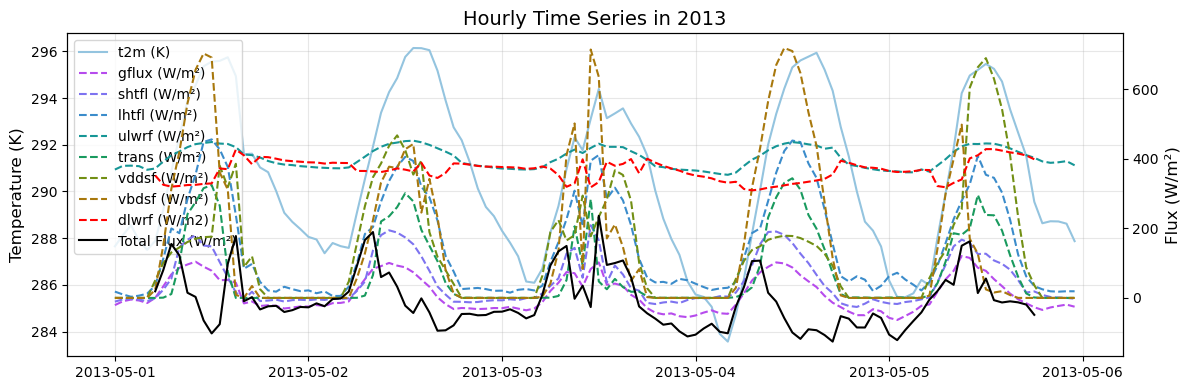

In [435]:
plot_combined_timeseries(
    dataset_temp=temperature_ds_clipped,
    dataset_flux=flux_ds_clipped,
    dataset_humidity=humidity_ds_clipped,
    temp_vars=['t2m'],
    flux_vars=['gflux', 'shtfl', 'lhtfl', 'ulwrf', 'trans', 'vddsf', 'vbdsf'],
    humidity_vars=['q2m'],
    timeslice=slice("2013-05-01", "2013-05-05"),
    average='hourly'
)

In [281]:
def regrid_to_precip(land_cover, target_lat, target_lon):
    """
    Regrid the land cover dataset to match the precipitation dataset.
    Each regridded tile is assigned proportions of land cover types 1, 2, 3, 4, and 5.

    Args:
        land_cover (xarray.DataArray): Original land cover dataset (lat, lon).
        target_lat (xarray.DataArray): Latitude coordinates of the target grid.
        target_lon (xarray.DataArray): Longitude coordinates of the target grid.

    Returns:
        xarray.DataArray: Regridded land cover proportions (type, lat, lon).
    """
    land_types = [1, 2, 3, 4, 5]  # Land cover types
    regridded = np.zeros((len(land_types), len(target_lat), len(target_lon)))

    dlat, dlon = target_lat[0] - target_lat[1], target_lon[1] - target_lon[0]

    for i, lat in enumerate(target_lat):
        for j, lon in enumerate(target_lon):
            # Find the indices of the original grid overlapping the target grid cell
            lat_mask = (land_cover['lat'] >= lat - dlat / 2) & (land_cover['lat'] < lat + dlat / 2)
            lon_mask = (land_cover['lon'] >= lon - dlon / 2) & (land_cover['lon'] < lon + dlon / 2)
            subgrid = land_cover.where(lat_mask & lon_mask, drop=True)

            # Calculate proportions for each land type
            if subgrid.size > 0:
                for k, land_type in enumerate(land_types):
                    regridded[k, i, j] = np.sum(subgrid.values == land_type) / subgrid.size
            else:
                regridded[:, i, j] = np.nan  # Assign NaN if no data is available in the subgrid

    return xr.DataArray(
        regridded,
        dims=('type', 'lat', 'lon'),
        coords={'type': land_types, 'lat': target_lat, 'lon': target_lon}
    )

In [282]:
def initialize_land_cover_data(land_cover_file, precip_ds):
    """
    Initialize the land cover data for the specified region.

    Args:
        land_cover_file (str): Path to the land cover file.
        precip_ds (xarray.Dataset): Precipitation dataset with latitude and longitude coordinates.

    Returns:
        regridded_land_cover (xarray.DataArray): Regridded land cover proportions (type, lat, lon).
        Wmax (xarray.DataArray): Weighted Wmax values for each grid cell (lat, lon).
    """
    # Load land cover data
    land_cover_ds = xr.open_dataset(land_cover_file)
    land_cover = land_cover_ds['land_cover_type']  # Assuming variable name is 'land_cover_type'

    # Regrid the land cover dataset to match the precipitation dataset
    regridded_land_cover = regrid_to_precip(land_cover, precip_ds['lat'], precip_ds['lon'])

    # Assign Wmax values for each land cover type
    Wmax_values = {
        1: 0.1,  # Asphalt
        2: 0.1,  # Bare soil
        3: 0.3,  # Soil with grass or cultures
        4: 0.4,  # Forest and shrubland
        5: 1.0   # Water body
    }

    # Compute weighted Wmax for each regridded tile
    Wmax = sum(regridded_land_cover.sel(type=land_type) * Wmax_values[land_type] for land_type in Wmax_values)

    return regridded_land_cover, Wmax


In [52]:
regridded_land_cover, regridded_Wmax = initialize_land_cover_data('land_cover_grouped.nc', precip_ds_clipped)

<xarray.DataArray 'lat' (lat: 2)> Size: 8B
array([45.52, 45.45], dtype=float32)
Coordinates:
  * lat      (lat) float32 8B 45.52 45.45
Attributes:
    standard_name:  latitude
    long_name:      latitude
    units:          degrees_north
    axis:           Y


In [29]:
display(regridded_Wmax)

<xarray.DataArray (lat: 2, lon: 4)> Size: 64B
array([[0.18683333, 0.15374317, 0.12194444, 0.14966667],
       [0.23230556, 0.14551913, 0.13644444, 0.18611111]])
Coordinates:
  * lat      (lat) float32 8B 45.52 45.45
  * lon      (lon) float32 16B 9.06 9.13 9.2 9.27
    type     int32 4B 5

In [57]:
def compute_soil_moisture(precip_ds, depth_levels, Wmax, temperature_ds, daytime_ratio):
    """
    Compute soil moisture from precipitation and land surface data.

    Args:
        precip_ds (xarray.Dataset): Precipitation dataset with variable 'tp' (time, lat, lon).
        depth_levels (numpy.ndarray): Depth levels for soil moisture computation.
        Wmax (xarray.DataArray): Weighted Wmax values for each grid cell (lat, lon).
        temperature_ds (xarray.Dataset): Dataset containing mean air temperature (time, lat, lon).
        daytime_ratio (float): Ratio of daytime hours in the considered period to a full year.

    Returns:
        xarray.DataArray: Soil moisture matrix (time, depth, lat, lon).
    """
    depth_step = depth_levels[1] - depth_levels[0]

    # Align coordinates of all datasets
    precip_ds = precip_ds.assign_coords(lat=Wmax['lat'], lon=Wmax['lon'])
    temperature_ds = temperature_ds.assign_coords(lat=Wmax['lat'], lon=Wmax['lon'])

    # Initialize soil moisture matrix
    soil_moisture = xr.DataArray(
        np.zeros((len(precip_ds['time']), len(depth_levels), len(precip_ds['lat']), len(precip_ds['lon']))),
        dims=('time', 'depth', 'lat', 'lon'),
        coords={'time': precip_ds['time'], 'depth': depth_levels, 'lat': precip_ds['lat'], 'lon': precip_ds['lon']}
    )

    # Parameters
    m = 2  # Nonlinearity coefficient
    a_prime = 0.01  # Drainage response coefficient
    a, b = -2, 1.5  # Evapotranspiration coefficients

    # Compute soil moisture over time
    for t in range(len(precip_ds['time'])):
        # Precipitation and temperature at time t
        p_t = precip_ds['tp'].isel(time=t)
        T_a = temperature_ds['t2m'].isel(time=t)

        # Potential evapotranspiration (ET_p)
        ET_p = a + b * (daytime_ratio * (0.46 * T_a + 8.13))

        # Upper soil layer, balance equation
        W = soil_moisture.isel(time=t - 1, depth=z) if t > 0 else xr.zeros_like(p_t)
        f_t = p_t * (1 - (W / Wmax) ** m)
        g_t = a_prime * W
        e_t = ET_p * (W / Wmax)
        dW_dt = f_t - g_t - e_t
        soil_moisture[t, 0, :, :] = (W + dW_dt).values
        
        # Richard's equation for deeper layers
        for z, depth in enumerate(depth_levels):
            if depth < 2:
                D = 0.1 * W  # Example diffusivity
                K = 0.01 * W  # Example hydraulic conductivity
            else:  # Sandy soil below 2m
                D = 0.1 * W  # Example diffusivity
                K = 0.01 * W  # Example hydraulic conductivity
            W = soil_moisture.isel(time=t - 1, depth=z) if t > 0 else xr.zeros_like(p_t)
            # Richard's equation for deeper layers, leapfrog method
            W_tm1_zm1 = soil_moisture.isel(time=t - 1, depth=z - 1).where(z<0, 0.)
            W_tm1_z = soil_moisture.isel(time=t - 1, depth=z).where(z<0, 0.)
            if z != len(depth_levels) - 1:
                W_tm1_zp1 = soil_moisture.isel(time=t - 1, depth=z+1).where(z<0, 0.)
            else: # last layer
                W_tm1_zp1 = 0
            dW_dt = 1.

            #dW_dt = (D * (W_tm1_zp1 - 2 * W_tm1_z + W_tm1_zm1) / (depth_step ** 2)) - (K * (W_tm1_z - W) / depth_step)
            soil_moisture[t, z, :, :] = (W + dW_dt).values
            # Ensure soil moisture is non-negative
            soil_moisture = xr.where(soil_moisture < 0, 0, soil_moisture)
            
    return soil_moisture


In [58]:
# Example parameters
depth_levels = np.arange(0, 8.1, 0.2)  # Depth levels from 0 to 8m with 0.2m intervals
daytime_ratio = 0.4  # Example ratio of daytime hours (adjust as needed)
land_cover_file = "land_cover_grouped.nc"  # Path to the land cover file

# Compute soil moisture using the function
computed_soil_moisture = compute_soil_moisture(
    precip_ds=precip_ds_clipped,
    depth_levels=depth_levels,
    Wmax=regridded_Wmax,
    temperature_ds=temperature_ds_clipped,
    daytime_ratio=daytime_ratio
)

# Select a time slice for comparison
time_slice = slice("2012-05-01", "2012-08-31")
computed_soil_moisture_slice = computed_soil_moisture.sel(time=time_slice)
soilw_slice = humidity_ds["soilw"].sel(time=time_slice)

# Plot the computed soil moisture
fig, axes = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

# Plot computed soil moisture
computed_soil_moisture_slice.sel(depth=0.25).mean(dim=["lat", "lon"]).plot(
    ax=axes[0], label="Computed Soil Moisture (0.25m)", color="blue"
)
computed_soil_moisture_slice.sel(depth=0.7).mean(dim=["lat", "lon"]).plot(
    ax=axes[0], label="Computed Soil Moisture (0.7m)", color="darkblue"
)
axes[0].set_title("Computed Soil Moisture")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Plot soilw from humidity_ds
soilw_slice.sel(depth=0.25).mean(dim=["lat", "lon"]).plot(
    ax=axes[1], label="Soilw (0.25m)", color="green"
)
soilw_slice.sel(depth=0.7).mean(dim=["lat", "lon"]).plot(
    ax=axes[1], label="Soilw (0.7m)", color="forestgreen"
)
axes[1].set_title("Soilw from humidity_ds")
axes[1].legend()
axes[1].grid(alpha=0.3)

# Adjust layout
plt.tight_layout()
plt.show()

KeyboardInterrupt: 

In [195]:
def calculate_matrices_thermal_properties_soil(soilw, 
                                               depth_levels=np.arange(0.0, 8.1, 0.2),
                                               a=5.77, m=2.0,
                                               C0= 6e6, c1=0):
    """
    Compute the matrices (depth, time) of the thermal properties of the soil: thermal conductivity, heat capacity.

    Args:
        soilw (xarray.DataArray): Soil moisture data (m³/m³).
    Returns:
        thermal_conductivity (xarray.DataArray): Thermal conductivity of the soil (W/m·K).
        heat_capacity (xarray.DataArray): Heat capacity of the soil (J/m³·K).
    """

    depth_step = depth_levels[1] - depth_levels[0]  # m
    num_depths = len(depth_levels)
    num_times = len(soilw.time)

    # interpolate soil moisture at desired depths (given as input)
    soilw_interpolated = soilw.interp(depth=depth_levels)
    soilw_interpolated = soilw_interpolated.fillna(0.2)

    # recompute the first layer with the Richard's equation from the layer below
    soilw_interpolated[:, 0] = soilw_interpolated[:, 1] - (soilw_interpolated[:, 1] - soilw_interpolated[:, 2]) * (depth_step / (depth_levels[1] - depth_levels[2]))
    
    # soil thermal property matrices
    soil_conductivity = a * soilw_interpolated**m  # W/(m·K) 
    # formula from GUAN Xiaodan et al., 2009. 
    # for an arid terrain of China, not ideally suited for Lombardy -> check climate and soil type

    #soil_heat_capacity = C0*np.exp(soilw_interpolated*c1)  # J/(m³·K) 
    soil_heat_capacity = C0*np.ones((num_times, num_depths)) + c1*soilw_interpolated  # J/(m³·K)
    # a bit random, following same GUAN Xiaodan et al., 2009. 
    # value should correspond to the type of ground cover -> check asphalt, sandy soil, ...

    return soilw_interpolated, soil_conductivity, soil_heat_capacity


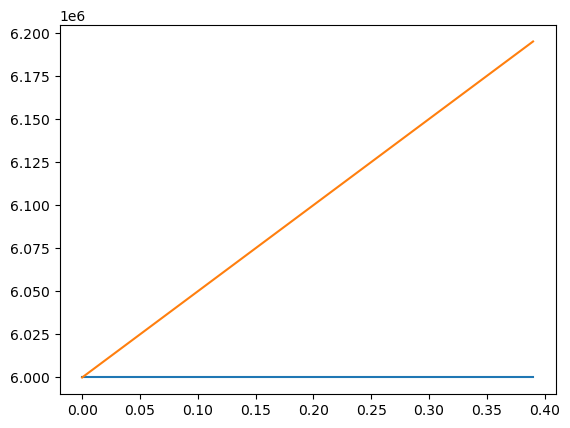

In [205]:
xx=np.arange(0.0, 0.4, 0.01)
yy = 6e6 + 0*xx
yy1 = 6e6 + 0.5*xx*1e6
plt.plot(xx, yy, label='Thermal conductivity')
plt.plot(xx, yy1, label='Thermal conductivity + 0.5*soilw*1e5')

plt.show()


In [443]:
def compute_dlwrf(vbdsf, vddsf, q2m, t2m, timeslice):
    """
    Compute the downward longwave radiation (dlwrf) using the air emissivity and temperature.
    The formula used is based on the Fairall method for clear sky conditions.
    """
    # Constants
    stefan_boltzmann_constant = 5.67e-8  # W/(m²·K⁴)
    air_emissivity_constant = 0.7  # Emissivity of air (assumed constant for simplicity)

    # cloudiness index (proxy for cloud cover)
    SWD_total = vbdsf + vddsf
    cloudiness_index = vbdsf / SWD_total
    cloudiness_index = cloudiness_index.interpolate_na(dim='time', method='linear')  # interpolate night's nan

    # Calculate air emissivity based on cloudiness index
    air_emissivity = air_emissivity_constant + 0.3 * cloudiness_index

    # Calculate dlwrf using the air emissivity and temperature
    dlwrf = air_emissivity * stefan_boltzmann_constant * (t2m**4)

    return dlwrf

In [460]:
def calculate_soil_temperature_profile(t2m, q2m, vbdsf, vddsf, lhtfl, shtfl, gflux, ulwrf, trans,
                                        depth_levels=np.arange(0, 8.1, 0.2), 
                                        soil_conductivity=1.5,  # W/(m·K)
                                        soil_heat_capacity=2.0e6,  # J/(m³·K)
                                        albedo=0.05,  # dimensionless
                                        time_step=3600):  # seconds
    """
    Calculate the underground temperature profile from the surface to 2m depth.

    Args:
        t2m (xarray.DataArray): Atmospheric temperature at 2m (K).
        q2m (xarray.DataArray): Atmospheric specific humidity (kg/kg).
        vbdsf (xarray.DataArray): Visible direct downward solar flux (W/m²).
        vddsf (xarray.DataArray): Visible diffuse downward solar flux (W/m²).
        lhtfl (xarray.DataArray): Latent heat flux (W/m²).
        shtfl (xarray.DataArray): Sensible heat flux (W/m²).
        gflux (xarray.DataArray): Ground heat flux (W/m²).
        ulwrf (xarray.DataArray): Upward longwave radiation (W/m²).
        trans (xarray.DataArray): evapotranspiration (W/m²).
        depth_levels (numpy.ndarray): Depth levels (m) from surface to 2m.
        soil_conductivity (float or xarray.Dataset): Soil thermal conductivity (W/(m·K)).
        soil_heat_capacity (float  or xarray.Dataset): Soil volumetric heat capacity (J/(m³·K)).
        albedo (float): Surface albedo (dimensionless).
        time_step (int): Time step for the simulation (seconds).

    Returns:
        xarray.DataArray: Timeseries of the underground temperature profile (K).
    """

    depth_step = depth_levels[1] - depth_levels[0]  # m
    num_depths = len(depth_levels)
    num_times = len(t2m.time)

    # ------------- SOIL PROPERTIES ---------------

    # soil conductivity
    if isinstance(soil_conductivity, (int, float)):
        soil_conductivity = np.ones((num_times, num_depths)) * soil_conductivity
    elif isinstance(soil_conductivity, xr.DataArray):
        # check is size is right
        if soil_conductivity.shape != (num_times, num_depths):
            raise ValueError("Soil conductivity matrix size does not match the expected dimensions.")
        else:
            soil_conductivity = soil_conductivity.values 

    # soil heat capacity
    if isinstance(soil_heat_capacity, (int, float)):
        soil_heat_capacity = np.ones((num_times, num_depths)) * soil_heat_capacity
    elif isinstance(soil_heat_capacity, xr.DataArray):
        # check is size is right
        if soil_heat_capacity.shape != (num_times, num_depths):
            raise ValueError("Soil heat capacity matrix size does not match the expected dimensions.")
        else:
            soil_heat_capacity = soil_heat_capacity.values 

    # thermal diffusivity
    thermal_diffusivity = soil_conductivity / soil_heat_capacity  # m²/s

    # --------------- INITIAL CONDITIONS ---------------

    # Calculate the Neumann number for the leapfrog scheme (also a matrix)
    neumann = thermal_diffusivity * time_step / (depth_step**2)

    # Initialize the temperature
    temperature_profile = np.ones((num_times, num_depths)) *280.15  # Initialize with a default value (e.g., 278.15 K)
    
    # Set initial conditions t=0 and t=1
    temperature_profile[0, :] = t2m[0].values
    temperature_profile[1, :] = t2m[1].values

    # ----------------- SURFACE FLUX ----------------

    # downward longwave radiation (dlwrf) 
    dlwrf = compute_dlwrf(vbdsf, vddsf, q2m, t2m, timeslice=slice(0, 1))

    # Calculate the net surface heat flux
    net_surface_flux = vbdsf + vddsf - ulwrf + dlwrf - lhtfl - shtfl + gflux - trans # Net surface energy balance  

    # -------------- LEAPFROG SCHEME -----------------

    for t in range(2, num_times):
        
        # Update surface temperature using balance at the ground
        surface_temp = t2m[t] 
        temperature_profile[t, 0] = surface_temp + gflux[t] / (soil_heat_capacity[t,0]*depth_step) * time_step

        # heat diffusion equation using leapfrog scheme
        for z in range(1, num_depths -1):
            d2T = (temperature_profile[t - 1, z + 1] - 2 * temperature_profile[t - 1, z] + temperature_profile[t - 1, z - 1] )
            temperature_profile[t, z] = temperature_profile[t - 1, z] + 2*neumann[t-1,z] * d2T 

    # replace by nan temperatures above 320K and below 250K
    temperature_profile = np.where((temperature_profile > 340) | (temperature_profile < 200), np.nan, temperature_profile)

    # Convert to xarray.DataArray
    temperature_da = xr.DataArray(
        temperature_profile,
        dims=["time", "depth"],
        coords={"time": t2m.time, "depth": depth_levels},
        attrs={"units": "K", "description": "Underground temperature profile"}
    )

    return temperature_da

In [487]:
timeslice=slice("2021-05-01", "2021-08-31")

# calculate soil properties for experiment 4
soilw_interpolated, soil_conductivity_4, soil_heat_capacity_4 = calculate_matrices_thermal_properties_soil(soilw=soilw_avg.sel(time=timeslice), a=5.77, m=.7, C0=6e6, c1=0)
_, soil_conductivity_5, soil_heat_capacity_5 = calculate_matrices_thermal_properties_soil(soilw=soilw_avg.sel(time=timeslice), a=5.77, m=0.7, C0=4e6, c1=0)
_, soil_conductivity_6, soil_heat_capacity_6 = calculate_matrices_thermal_properties_soil(soilw=soilw_avg.sel(time=timeslice), a=5.77, m=0.7, C0=6e6, c1=0)

list_experiments = {
    'experiment_1': {
        't2m': t2m_avg.sel(time=timeslice),
        'q2m': q2m_avg.sel(time=timeslice),
        'vbdsf': vbdsf_avg.sel(time=timeslice),
        'vddsf': vddsf_avg.sel(time=timeslice),
        'lhtfl': lhtfl_avg.sel(time=timeslice),
        'shtfl': shtfl_avg.sel(time=timeslice),
        'gflux': gflux_avg.sel(time=timeslice),
        'ulwrf': ulwrf_avg.sel(time=timeslice),
        'trans': trans_avg.sel(time=timeslice),
        'soilw': soilw_avg.sel(time=timeslice),
        'soil_conductivity':.5,
        'soil_heat_capacity':6e6,
    },
    # 'experiment_2': {
    #     't2m': t2m_avg.sel(time=timeslice),
    #     'q2m': q2m_avg.sel(time=timeslice),
    #     'vbdsf': vbdsf_avg.sel(time=timeslice),
    #     'vddsf': vddsf_avg.sel(time=timeslice),
    #     'lhtfl': lhtfl_avg.sel(time=timeslice),
    #     'shtfl': shtfl_avg.sel(time=timeslice),
    #     'gflux': gflux_avg.sel(time=timeslice),
    #     'ulwrf': ulwrf_avg.sel(time=timeslice),
    #     'trans': trans_avg.sel(time=timeslice),
    #     'soilw': soilw_avg.sel(time=timeslice),
    #     'soil_conductivity':.5,
    #     'soil_heat_capacity':6e6,
    # },
    # 'experiment_3': {
    #     't2m': t2m_avg.sel(time=timeslice),
    #     'q2m': q2m_avg.sel(time=timeslice),
    #     'vbdsf': vbdsf_avg.sel(time=timeslice),
    #     'vddsf': vddsf_avg.sel(time=timeslice),
    #     'lhtfl': lhtfl_avg.sel(time=timeslice),
    #     'shtfl': shtfl_avg.sel(time=timeslice),
    #     'gflux': gflux_avg.sel(time=timeslice),
    #     'ulwrf': ulwrf_avg.sel(time=timeslice),
    #     'trans': trans_avg.sel(time=timeslice),
    #     'soilw': soilw_avg.sel(time=timeslice),
    #     'soil_conductivity':.5,
    #     'soil_heat_capacity':6e6,
    # },
    'experiment_4': {
        't2m': t2m_avg.sel(time=timeslice),
        'q2m': q2m_avg.sel(time=timeslice),
        'vbdsf': vbdsf_avg.sel(time=timeslice),
        'vddsf': vddsf_avg.sel(time=timeslice),
        'lhtfl': lhtfl_avg.sel(time=timeslice),
        'shtfl': shtfl_avg.sel(time=timeslice),
        'gflux': gflux_avg.sel(time=timeslice),
        'ulwrf': ulwrf_avg.sel(time=timeslice),
        'trans': trans_avg.sel(time=timeslice),
        'soilw': soilw_avg.sel(time=timeslice),
        'soil_conductivity':soil_conductivity_4,
        'soil_heat_capacity':soil_heat_capacity_4,
    },
    # 'experiment_5': {
    #     't2m': t2m_avg.sel(time=timeslice),
    #     'q2m': q2m_avg.sel(time=timeslice),
    #     'vbdsf': vbdsf_avg.sel(time=timeslice),
    #     'vddsf': vddsf_avg.sel(time=timeslice),
    #     'lhtfl': lhtfl_avg.sel(time=timeslice),
    #     'shtfl': shtfl_avg.sel(time=timeslice),
    #     'gflux': gflux_avg.sel(time=timeslice),
    #     'ulwrf': ulwrf_avg.sel(time=timeslice),
    #     'trans': trans_avg.sel(time=timeslice),
    #     'soilw': soilw_avg.sel(time=timeslice),
    #     'soil_conductivity':soil_conductivity_5,
    #     'soil_heat_capacity':soil_heat_capacity_5,
    # },
    # 'experiment_6': {
    #     't2m': t2m_avg.sel(time=timeslice),
    #     'vbdsf': vbdsf_avg.sel(time=timeslice),
    #     'vddsf': vddsf_avg.sel(time=timeslice),
    #     'lhtfl': lhtfl_avg.sel(time=timeslice),
    #     'shtfl': shtfl_avg.sel(time=timeslice),
    #     'gflux': gflux_avg.sel(time=timeslice),
    #     'ulwrf': ulwrf_avg.sel(time=timeslice),
    #     'soilw': soilw_avg.sel(time=timeslice),
    #     'soil_conductivity':soil_conductivity_6,
    #     'soil_heat_capacity':soil_heat_capacity_6,
    # },
}

# Calculate the underground temperature profile for each experiment
temperature_profiles = {}
for exp_name, exp_data in list_experiments.items():
    temperature_profiles[exp_name] = calculate_soil_temperature_profile(
        t2m=exp_data['t2m'],
        q2m=exp_data['q2m'],
        vbdsf=exp_data['vbdsf'],
        vddsf=exp_data['vddsf'],
        lhtfl=exp_data['lhtfl'],
        shtfl=exp_data['shtfl'],
        gflux=exp_data['gflux'],
        ulwrf=exp_data['ulwrf'],
        trans=exp_data['trans'],
        depth_levels=np.arange(0, 8.1, 0.2),
        soil_conductivity=exp_data['soil_conductivity'],
        soil_heat_capacity=exp_data['soil_heat_capacity']
    )


ValueError: Soil conductivity matrix size does not match the expected dimensions.

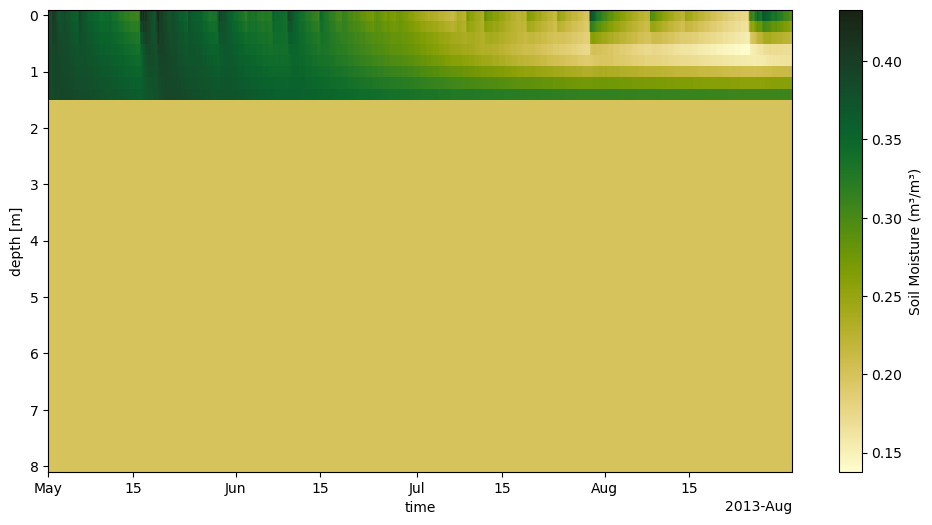

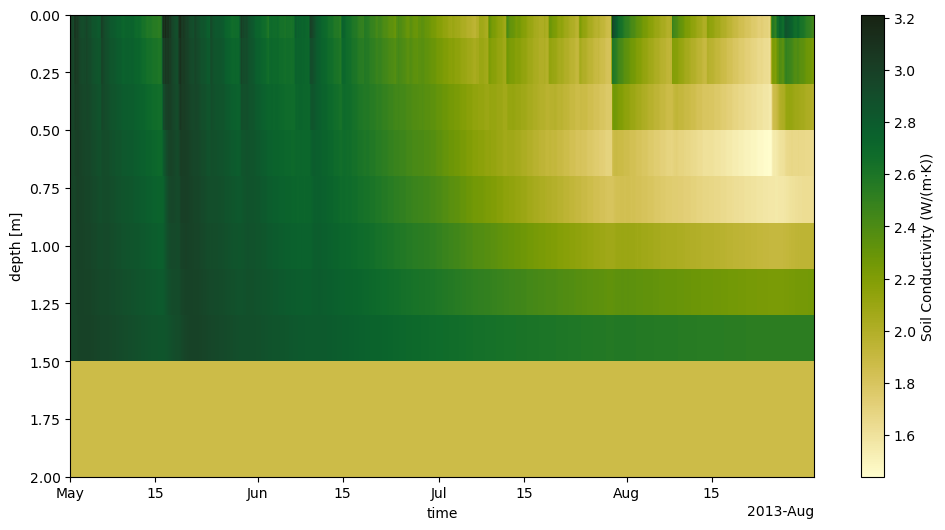

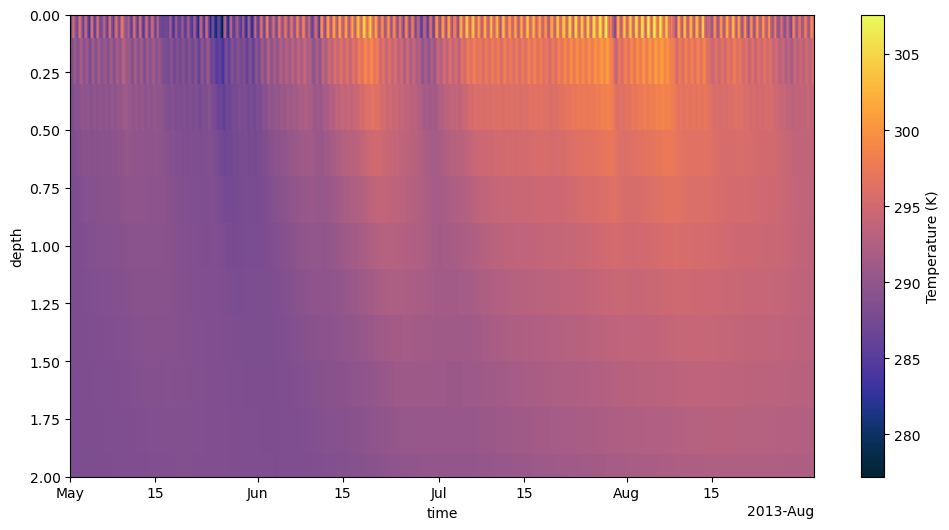

In [ ]:
# plot time, depth soilw interpolated for experiment 4
fig, ax = plt.subplots(figsize=(12, 6))
soilw_interpolated.plot(
    ax=ax, 
    x='time', 
    y='depth', 
    cmap=cmocean.cm.speed, 
    cbar_kwargs={'label': 'Soil Moisture (m³/m³)'},
    yincrease=False,  # Invert y-axis for depth
)
plt.show()
# plot soil conductivity
fig, ax = plt.subplots(figsize=(12, 6))
soil_conductivity_4.plot(
    ax=ax, 
    x='time', 
    y='depth', 
    ylim=(2,0),
    cmap=cmocean.cm.speed, 
    cbar_kwargs={'label': 'Soil Conductivity (W/(m·K))'},
    yincrease=False,  # Invert y-axis for depth
)
plt.show()

# plot temperature profiles for experiment 4
fig, ax = plt.subplots(figsize=(12, 6))
temperature_profiles['experiment_4'].plot(
    ax=ax, 
    x='time', 
    y='depth', 
    ylim=(2,0),
    cmap=cmocean.cm.thermal, 
    cbar_kwargs={'label': 'Temperature (K)'},
    yincrease=False,  # Invert y-axis for depth
)
plt.show()


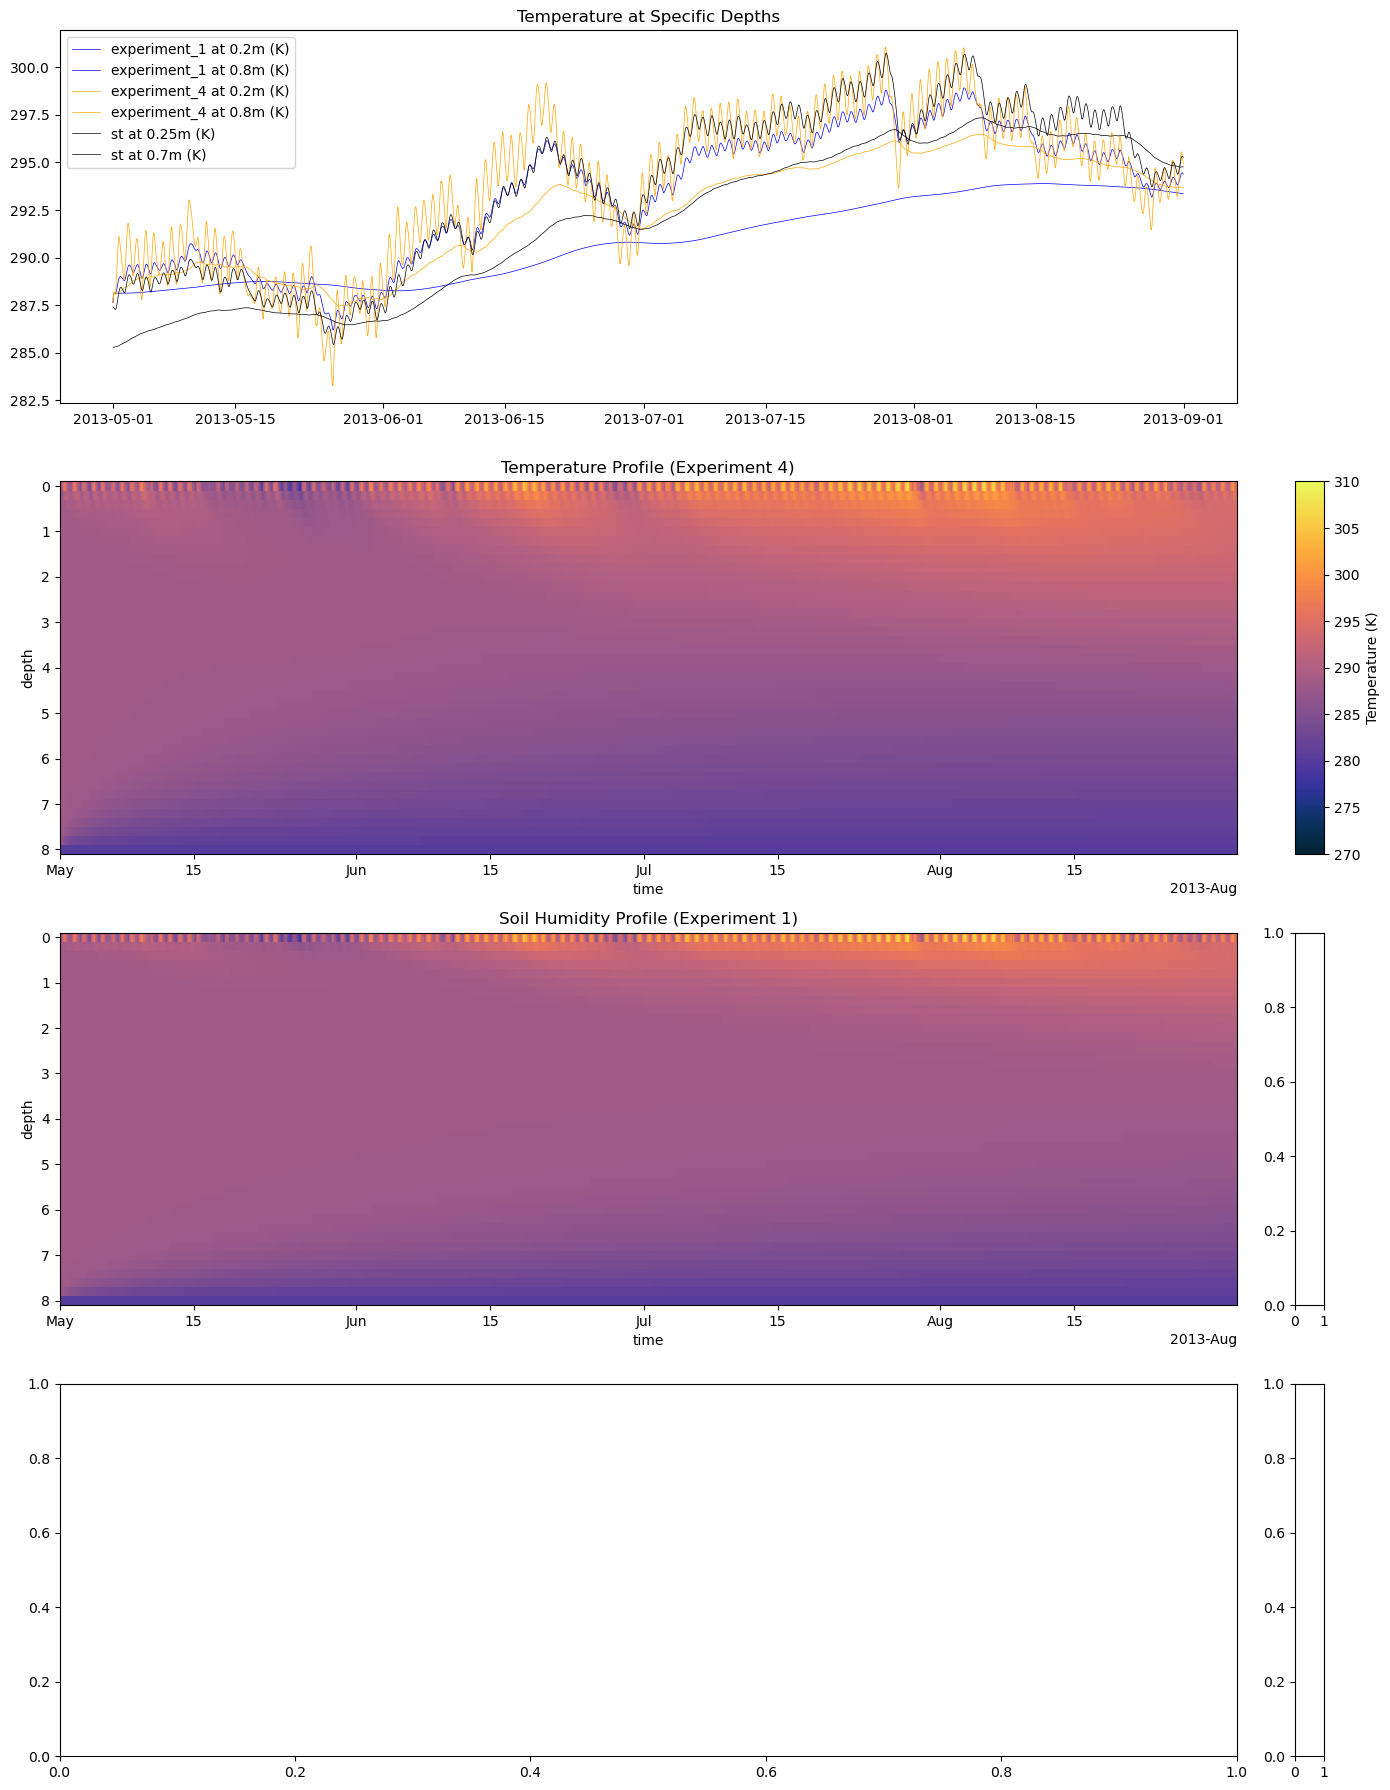

In [484]:
# Create a figure with GridSpec to allocate space for colorbars
fig = plt.figure(figsize=(14, 18))
gs = GridSpec(4, 2, width_ratios=[20, 0.5], height_ratios=[1, 1, 1, 1], figure=fig)

# Create subplots
ax0 = fig.add_subplot(gs[0, 0])  # First plot (no colorbar)
ax1 = fig.add_subplot(gs[1, 0])  # Second plot (temperature profile)
ax2 = fig.add_subplot(gs[2, 0])  # Third plot (soil humidity profile)
ax3 = fig.add_subplot(gs[3, 0])  # Fourth plot (thermal conductivity profile)

# Create colorbar axes
cbar_ax1 = fig.add_subplot(gs[1, 1])  # Colorbar for temperature profile
cbar_ax2 = fig.add_subplot(gs[2, 1])  # Colorbar for soil humidity profile
cbar_ax3 = fig.add_subplot(gs[3, 1])  # Colorbar for thermal conductivity profile

# Plot temperature at 0.2m and 0.8m for all experiments
colors = ['blue', 'orange', 'green', 'red', 'purple', 'brown', 'pink']
for experiment, temperature_profile in temperature_profiles.items():
    #display(temperature_profile)
    color = colors.pop(0)  # Get a color from the list
    ax0.plot(
        temperature_profile.time,
        temperature_profile.sel(depth=0.2),
        label=f'{experiment} at 0.2m (K)',
        linewidth=0.5,
        color=color
    )
    ax0.plot(
        temperature_profile.time,
        temperature_profile.sel(depth=0.8),
        label=f'{experiment} at 0.8m (K)',
        linewidth=0.5,
        color=color,
    )

# Plot MERIDA temperature at 0.25m and 0.7m for the comparison
ax0.plot(
    st_avg.sel(time=timeslice).time,
    st_avg.sel(time=timeslice, depth=0.25),
    color='k',
    label='st at 0.25m (K)',
    linewidth=0.5
)
ax0.plot(
    st_avg.sel(time=timeslice).time,
    st_avg.sel(time=timeslice, depth=0.7),
    color='k',
    label='st at 0.7m (K)',
    linewidth=0.5
)
ax0.legend()
ax0.set_title("Temperature at Specific Depths")

# Plot the heatmap (Hovmöller plot) for temperature profile

temperature_profiles['experiment_4'].plot(
    x="time",
    y="depth",
    cmap="cmo.thermal",
    yincrease=False,
    cbar_kwargs={"label": "Temperature (K)", "cax": cbar_ax1},
    ax=ax1,
    vmin=270,
    vmax=310,
)
ax1.set_title("Temperature Profile (Experiment 4)")

temperature_profiles['experiment_1'].plot(
    x="time",
    y="depth",
    cmap="cmo.thermal",
    yincrease=False,
    cbar_kwargs={"label": "Temperature (K)", "cax": cbar_ax1},
    ax=ax2,
    vmin=270,
    vmax=310,
)
ax2.set_title("Soil Humidity Profile (Experiment 1)")


# Adjust layout
plt.tight_layout()
plt.show()

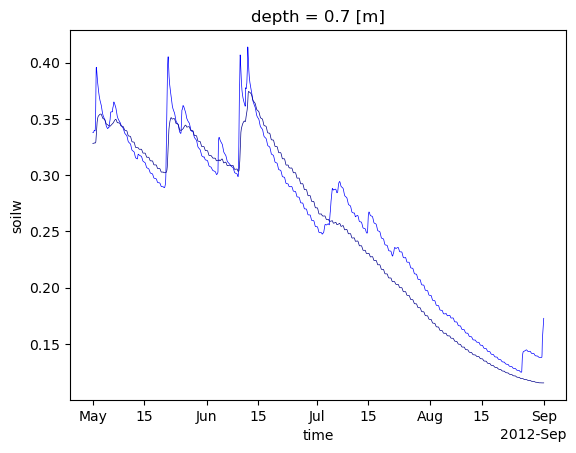

In [467]:
soilw_avg.sel(time=slice("2012-05-01", "2012-08-31"), depth=0.25).plot(
    x="time", 
    color='blue', 
    label='soilw at 0.25m (%)', 
    linewidth=0.5,
)
soilw_avg.sel(time=slice("2012-05-01", "2012-08-31"), depth=0.7).plot(
    x="time", 
    color='darkblue', 
    label='soilw at 0.7m (m3/m3)', 
    linewidth=0.5,
)